In [1]:
!pip -q install einops

import torch
import torch.nn as nn
from einops import rearrange
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [2]:
image = torch.randn(1, 3, 32, 32)

patch_size = 4
embed_dim = 64
num_heads = 4

print("Image shape:", image.shape)

Image shape: torch.Size([1, 3, 32, 32])


In [3]:
class PatchProjection(nn.Module):

    def __init__(self):
        super().__init__()

        self.proj = nn.Conv2d(
            3, embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):

        x = self.proj(x)

        return rearrange(
            x,
            "b c h w -> b (h w) c"
        )

In [4]:
class Attention(nn.Module):

    def __init__(self):
        super().__init__()

        self.qkv = nn.Linear(
            embed_dim,
            embed_dim * 3
        )

        self.out = nn.Linear(
            embed_dim,
            embed_dim
        )

    def forward(self, x):

        q, k, v = self.qkv(x).chunk(3, dim=-1)

        q = rearrange(
            q, "b n (h d) -> b h n d",
            h=num_heads
        )

        k = rearrange(
            k, "b n (h d) -> b h n d",
            h=num_heads
        )

        v = rearrange(
            v, "b n (h d) -> b h n d",
            h=num_heads
        )

        scores = q @ k.transpose(-2, -1)
        scores /= q.shape[-1] ** 0.5

        attention = scores.softmax(dim=-1)

        out = attention @ v

        out = rearrange(
            out,
            "b h n d -> b n (h d)"
        )

        return self.out(out), attention

In [5]:
class ViTBlock(nn.Module):

    def __init__(self):
        super().__init__()

        self.patch = PatchProjection()

        num_patches = (32 // patch_size) ** 2

        self.cls = nn.Parameter(
            torch.randn(1, 1, embed_dim)
        )

        self.pos = nn.Parameter(
            torch.randn(
                1,
                num_patches + 1,
                embed_dim
            )
        )

        self.attention = Attention()

    def forward(self, x):

        x = self.patch(x)

        cls = self.cls.expand(
            x.size(0), -1, -1
        )

        x = torch.cat([cls, x], dim=1)

        x = x + self.pos

        return self.attention(x)

In [6]:
model = ViTBlock()

output, attention = model(image)

print("Token output:", output.shape)
print("Attention:", attention.shape)

Token output: torch.Size([1, 65, 64])
Attention: torch.Size([1, 4, 65, 65])


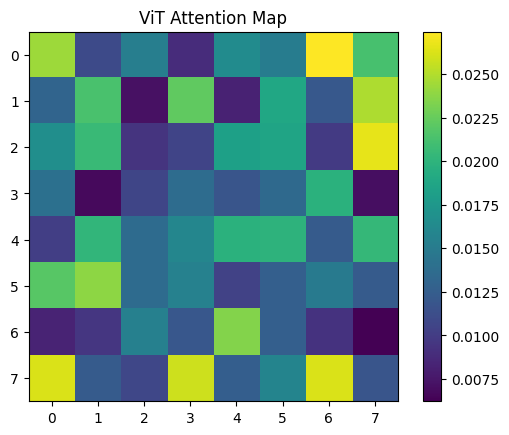

In [7]:
attn = attention[0, 0, 0, 1:]

attn = attn.reshape(
    32 // patch_size,
    32 // patch_size
).detach()

plt.imshow(attn, cmap="viridis")
plt.title("ViT Attention Map")
plt.colorbar()
plt.show()

In [8]:
print("Vision Transformer patch projection completed.")
print("Multi-head self-attention and attention visualization completed.")

Vision Transformer patch projection completed.
Multi-head self-attention and attention visualization completed.
